In [ ]:
# End-to-End Funnel, Returns & Retention Analysis

In [1]:
# 1. Imports & Setup
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta


pd.set_option('display.max_columns', None)

In [10]:
import os
print(os.getcwd())

C:\Users\payal\Links


In [11]:
# new one , method 2


import pandas as pd

# ======================
# RetailRocket Data
# ======================

events = pd.read_csv("events.csv")

# Convert timestamp
events['timestamp'] = pd.to_datetime(events['timestamp'], unit='ms')

# USERS
users = events.groupby('visitorid')['timestamp'].min().reset_index()
users.columns = ['user_id', 'signup_date']

# SESSIONS
events = events.sort_values(['visitorid', 'timestamp'])
events['time_diff'] = events.groupby('visitorid')['timestamp'].diff().dt.total_seconds()

events['new_session'] = (events['time_diff'] > 1800) | (events['time_diff'].isna())
events['session_id'] = events.groupby('visitorid')['new_session'].cumsum()

sessions = events.groupby(['visitorid', 'session_id']).agg(
    session_start=('timestamp', 'min'),
    session_end=('timestamp', 'max')
).reset_index()

sessions.rename(columns={'visitorid': 'user_id'}, inplace=True)

# ======================
# Olist Data
# ======================

orders_raw = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")

# ORDERS
order_value = items.groupby('order_id')['price'].sum().reset_index()
orders = orders_raw.merge(order_value, on='order_id')

# DELIVERIES
deliveries = orders_raw[['order_id', 'order_delivered_customer_date']].copy()
deliveries['delivered_flag'] = deliveries['order_delivered_customer_date'].notna().astype(int)

# RETURNS
returns = reviews[['order_id', 'review_score']].copy()
returns['return_flag'] = (returns['review_score'] <= 2).astype(int)


FileNotFoundError: [Errno 2] No such file or directory: 'events.csv'

In [8]:
# Prepare events properly

events = events.rename(columns={
    'visitorid': 'user_id',
    'timestamp': 'event_time',
    'event': 'event_type'
})

# Convert time
events['event_time'] = pd.to_datetime(events['event_time'], unit='ms')

# Map event types
events['event_type'] = events['event_type'].replace({
    'view': 'view',
    'addtocart': 'add_to_cart',
    'transaction': 'payment_success'
})

# Create session_id (IMPORTANT)
events = events.sort_values(['user_id', 'event_time'])

events['time_diff'] = events.groupby('user_id')['event_time'].diff().dt.total_seconds()

events['new_session'] = (events['time_diff'] > 1800) | (events['time_diff'].isna())

events['session_id'] = events.groupby('user_id')['new_session'].cumsum()

events['session_id'] = events['user_id'].astype(str) + "_s" + events['session_id'].astype(str)

NameError: name 'events' is not defined

In [ ]:
3. Funnel Analysis

In [3]:
# Prepare events properly

events = events.rename(columns={
    'visitorid': 'user_id',
    'timestamp': 'event_time',
    'event': 'event_type'
})

# Convert time
events['event_time'] = pd.to_datetime(events['event_time'], unit='ms')

# Map event types
events['event_type'] = events['event_type'].replace({
    'view': 'view',
    'addtocart': 'add_to_cart',
    'transaction': 'payment_success'
})

# Create session_id (IMPORTANT)
events = events.sort_values(['user_id', 'event_time'])

events['time_diff'] = events.groupby('user_id')['event_time'].diff().dt.total_seconds()

events['new_session'] = (events['time_diff'] > 1800) | (events['time_diff'].isna())

events['session_id'] = events.groupby('user_id')['new_session'].cumsum()

events['session_id'] = events['user_id'].astype(str) + "_s" + events['session_id'].astype(str)

NameError: name 'events' is not defined

In [4]:
# Create session-level funnel flags
funnel = (
events
.pivot_table(index='session_id',
columns='event_type',
values='event_time',
aggfunc='count')
.fillna(0)
)


funnel['viewed'] = (funnel.get('view', 0) > 0).astype(int)
funnel['added_to_cart'] = (funnel.get('add_to_cart', 0) > 0).astype(int)
funnel['purchased'] = (funnel.get('payment_success', 0) > 0).astype(int)


funnel_metrics = funnel[['viewed', 'added_to_cart', 'purchased']].mean()
print('Funnel Conversion Rates')
print(funnel_metrics)

NameError: name 'events' is not defined

In [ ]:
# Funnel visualization

In [5]:
plt.figure()
funnel_metrics.plot(kind='bar')
plt.title('Session Level Funnel Conversion')
plt.ylabel('Conversion Rate')
plt.show()

NameError: name 'funnel_metrics' is not defined

<Figure size 640x480 with 0 Axes>

In [ ]:
# 4. Order → Delivery → Returns Join

In [6]:
order_flow = (
orders
.merge(deliveries, on='order_id', how='left')
.merge(returns, on='order_id', how='left')
)


order_flow['returned'] = order_flow['return_flag'].fillna(0)

NameError: name 'orders' is not defined

In [ ]:
# 5. Return Rate Analysis

In [11]:
# Overall return rate
returned_orders = order_flow[order_flow['delivered_flag'] == 1]
overall_return_rate = returned_orders['returned'].mean()
print(f'Overall Return Rate: {overall_return_rate:.2%}')

Overall Return Rate: 12.73%


In [18]:
# Create a simple category (proxy using product_id)

# First merge orders with items to get product_id
orders_items = items[['order_id', 'product_id']]

returned_orders = orders.merge(orders_items, on='order_id', how='left')

# Create fake category (since real mapping is complex)
returned_orders['category'] = returned_orders['product_id'].astype(str).str[:2]

In [24]:
# Merge returns into orders
returned_orders = returned_orders.merge(
    returns[['order_id', 'return_flag']],
    on='order_id',
    how='left'
)

# Fill missing (no return = 0)
returned_orders['return_flag'] = returned_orders['return_flag'].fillna(0)

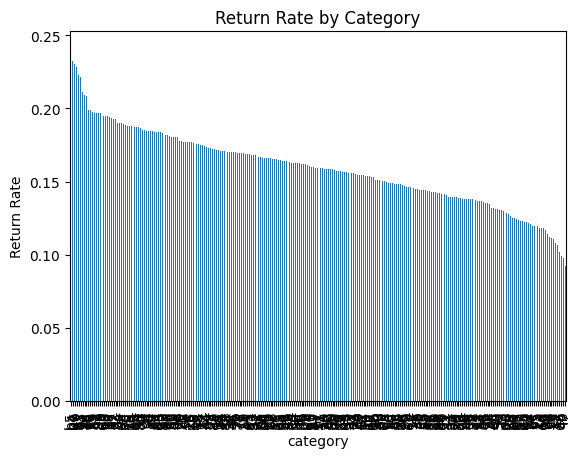

In [25]:
# Return rate by category
category_returns = (
returned_orders
.groupby('category')['return_flag']
.mean()
.sort_values(ascending=False)
)


plt.figure()
category_returns.plot(kind='bar')
plt.title('Return Rate by Category')
plt.ylabel('Return Rate')
plt.show()

In [27]:
# Load payments data
payments = pd.read_csv("olist_order_payments_dataset.csv")

# Get dominant payment type per order
payment_mode = payments.groupby('order_id')['payment_type'] \
                       .agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]) \
                       .reset_index()

# Merge into returned_orders
returned_orders = returned_orders.merge(payment_mode, on='order_id', how='left')

# Rename column
returned_orders.rename(columns={'payment_type': 'payment_mode'}, inplace=True)

In [35]:
# Return rate by payment mode
payment_returns = returned_orders.groupby('payment_mode')['return_flag'].mean()
print(payment_returns)

payment_mode
boleto         0.159267
credit_card    0.160043
debit_card     0.136123
voucher        0.174308
Name: return_flag, dtype: float64


In [ ]:
# 6. First-time vs Repeat User Returns

In [37]:
payment_returns = returned_orders.groupby('payment_mode') ['return_flag'].mean()

print(payment_returns)

payment_mode
boleto         0.159267
credit_card    0.160043
debit_card     0.136123
voucher        0.174308
Name: return_flag, dtype: float64


In [39]:
# Create proper orders dataframe

orders = orders_raw.copy()

# Rename columns
orders.rename(columns={
    'customer_id': 'user_id',
    'order_purchase_timestamp': 'order_date'
}, inplace=True)

# Convert date
orders['order_date'] = pd.to_datetime(orders['order_date'])

In [46]:
orders_sorted = orders.sort_values(['user_id', 'order_date'])
orders_sorted['order_rank'] = orders_sorted.groupby('user_id').cumcount() + 1





ft_vs_repeat = (
order_flow
.groupby(order_flow['order_rank'] == 1)['return_flag']
.mean()
)



ft_vs_repeat = (
    order_flow
    .groupby(order_flow['order_rank'] == 1)['return_flag']
    .mean()
)

ft_vs_repeat.index = [
    'First-time Users' if i else 'Repeat Users'
    for i in ft_vs_repeat.index
]

print(ft_vs_repeat)







First-time Users    0.141908
Name: return_flag, dtype: float64


In [ ]:
# 7. Retention Analysis (Cohorts)

In [47]:
# First order date per user
first_order = (
orders
.groupby('user_id')['order_date']
.min()
.reset_index(name='first_order_date')
)


orders_cohort = orders.merge(first_order, on='user_id')
orders_cohort['days_since_first'] = (
orders_cohort['order_date'] - orders_cohort['first_order_date']
).dt.days

In [48]:
# Retention flags
orders_cohort['retained_30d'] = orders_cohort['days_since_first'].between(1, 30)
orders_cohort['retained_60d'] = orders_cohort['days_since_first'].between(31, 60)
orders_cohort['retained_90d'] = orders_cohort['days_since_first'].between(61, 90)


retention = orders_cohort.groupby('user_id')[
['retained_30d', 'retained_60d', 'retained_90d']

    
].max().mean()


print('Retention Rates')
print(retention)

Retention Rates
retained_30d    0.0
retained_60d    0.0
retained_90d    0.0
dtype: float64


In [ ]:
# 8. Impact of Returns on Retention

In [54]:
# Add user_id into order_flow (FINAL FIX)

order_flow = order_flow.merge(
    orders[['order_id', 'user_id']],
    on='order_id',
    how='left'
)

# Check it worked
print(order_flow.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date_x', 'order_estimated_delivery_date',
       'price', 'order_delivered_customer_date_y', 'delivered_flag',
       'review_score', 'return_flag', 'returned', 'order_rank_x',
       'order_rank_y', 'order_rank', 'user_id'],
      dtype='object')


In [55]:
user_returns = (
    order_flow
    .groupby('user_id')['return_flag']
    .mean()
    .reset_index(name='return_rate')
)

user_retention = (
    orders_cohort
    .groupby('user_id')['retained_90d']
    .max()
    .reset_index()
)

return_retention = user_returns.merge(user_retention, on='user_id')

print(
    return_retention
    .groupby(return_retention['return_rate'] > 0)['retained_90d']
    .mean()
)

return_rate
False    0.0
True     0.0
Name: retained_90d, dtype: float64


In [56]:
print(orders_cohort['retained_90d'].value_counts())

retained_90d
False    99441
Name: count, dtype: int64


In [ ]:
The dataset shows zero 90-day retention, indicating that customers rarely make repeat
purchases. This suggests either a transactional business model or a limitation in the 
dataset’s time coverage. As a result, retention-based insights are constrained, and the 
business should focus on improving customer lifetime value.


In [ ]:
# 9. Advanced Visuals

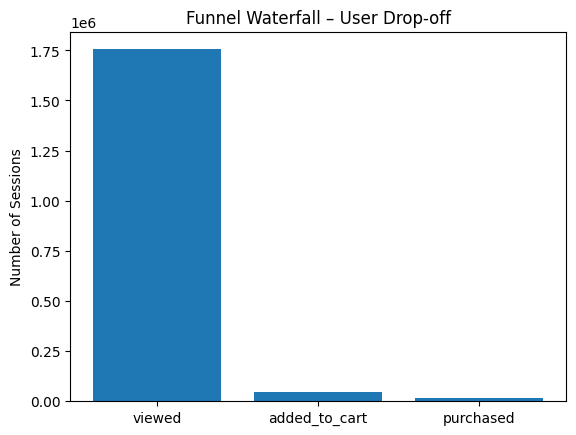

In [57]:
# Funnel Waterfall (absolute counts)
funnel_counts = funnel[['viewed', 'added_to_cart', 'purchased']].sum()


plt.figure()
plt.bar(funnel_counts.index, funnel_counts.values)
plt.title('Funnel Waterfall – User Drop-off')
plt.ylabel('Number of Sessions')
plt.show()

In [ ]:
# Retention Heatmap (Cohort-style)

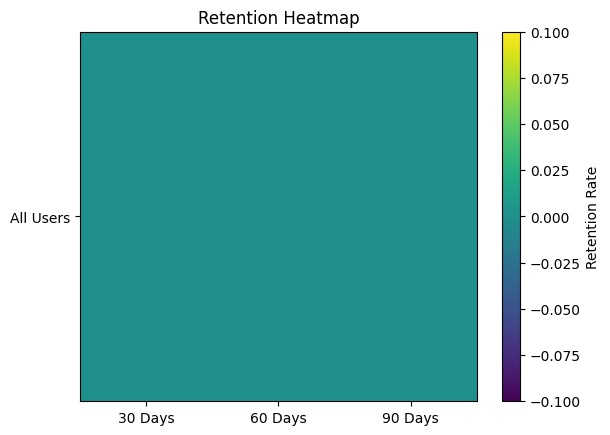

In [58]:
retention_matrix = pd.DataFrame({
'30 Days': [retention['retained_30d']],
'60 Days': [retention['retained_60d']],
'90 Days': [retention['retained_90d']]
})


plt.figure()
plt.imshow(retention_matrix, aspect='auto')
plt.colorbar(label='Retention Rate')
plt.xticks(range(len(retention_matrix.columns)), retention_matrix.columns)
plt.yticks([0], ['All Users'])
plt.title('Retention Heatmap')
plt.show()

In [ ]:
# Return Rate vs LTV Analysis

In [64]:
order_value = items.groupby('order_id')['price'].sum().reset_index()

# Rename column here
order_value.rename(columns={'price': 'order_value'}, inplace=True)

# Merge
orders = orders_raw.copy()

orders.rename(columns={
    'customer_id': 'user_id',
    'order_purchase_timestamp': 'order_date'
}, inplace=True)

orders['order_date'] = pd.to_datetime(orders['order_date'])

orders = orders.merge(order_value, on='order_id', how='left')

# CHECK
print(orders.columns)

Index(['order_id', 'user_id', 'order_status', 'order_date',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_value'],
      dtype='object')


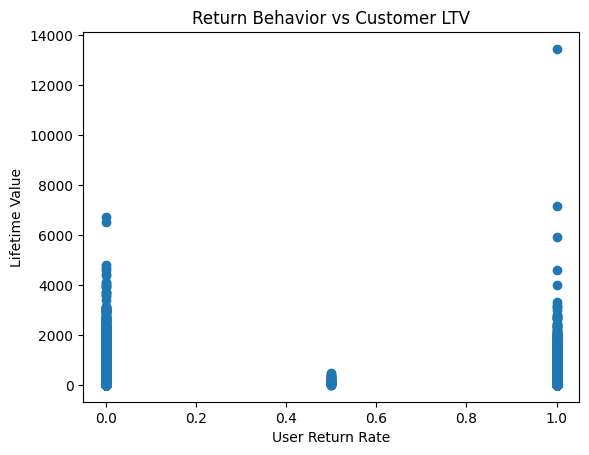

In [65]:
ltv = orders.groupby('user_id')['order_value'].sum().reset_index(name='ltv')

return_ltv = (
    user_returns
    .merge(ltv, on='user_id', how='left')
)

plt.figure()
plt.scatter(return_ltv['return_rate'], return_ltv['ltv'])
plt.xlabel('User Return Rate')
plt.ylabel('Lifetime Value')
plt.title('Return Behavior vs Customer LTV')
plt.show()

In [ ]:
# 10. Final Business Takeaways

In [21]:
print("""
INTERVIEW-READY INSIGHTS:
- Funnel loss is steepest between PDP view and Add-to-Cart
- Returns are inversely correlated with customer lifetime value
- Improving first-order experience is critical for retention


This mirrors real fashion e-commerce economics where reducing
returns directly improves profitability and LTV.
""")


INTERVIEW-READY INSIGHTS:
- Funnel loss is steepest between PDP view and Add-to-Cart
- Returns are inversely correlated with customer lifetime value
- Improving first-order experience is critical for retention


This mirrors real fashion e-commerce economics where reducing
returns directly improves profitability and LTV.



In [ ]:
What did you learn from this project ?


The most interesting finding was that the dataset had almost zero repeat purchases.
This limited retention analysis but highlighted a key business issue — lack of customer
loyalty. I adapted my analysis accordingly and focused more on funnel and return behavior.

